In [1]:
import numpy as np 
from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec

In [2]:
glove2word2vec('datasets/test_glove.txt', 'datasets/test_wv.txt')

/tmp/ipykernel_76878/40271968.py:1: DeprecationWarning: Call to deprecated `glove2word2vec` (KeyedVectors.load_word2vec_format(.., binary=False, no_header=True) loads GLoVE text vectors.).
  glove2word2vec('datasets/test_glove.txt', 'datasets/test_wv.txt')


(8, 4)

In [3]:
model = KeyedVectors.load_word2vec_format('datasets/test_wv.txt', 
                                         binary=False)

In [5]:
model.similarity('king','queen')

0.9998945

In [6]:
model.similarity('mango','apple')

0.99897045

In [7]:
model.similarity('computer','woman')

-0.61038744

In [8]:
model.similarity('king','apple')

0.48034889

In [9]:
model.most_similar('keyboard', topn=1)

[('computer', 0.9996708035469055)]

In [10]:
model.most_similar(positive= ['king','woman'], negative=['man'], topn=1)

[('queen', 0.9998007416725159)]

#### Visualize

In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [13]:
pca = PCA(n_components=2, random_state=0)

In [14]:
vectors_2d = pca.fit_transform(model.vectors)

In [15]:
vectors_2d

array([[-0.68762094, -0.35608187],
       [-0.75699544, -0.3840753 ],
       [-0.39322   , -0.14959295],
       [-0.46259448, -0.17758615],
       [-0.38705274,  0.6145131 ],
       [-0.35946837,  0.59929866],
       [ 1.4869584 , -0.07137657],
       [ 1.5599931 , -0.07509927]], dtype=float32)

In [16]:
model.index_to_key

['king', 'queen', 'man', 'woman', 'apple', 'mango', 'computer', 'keyboard']

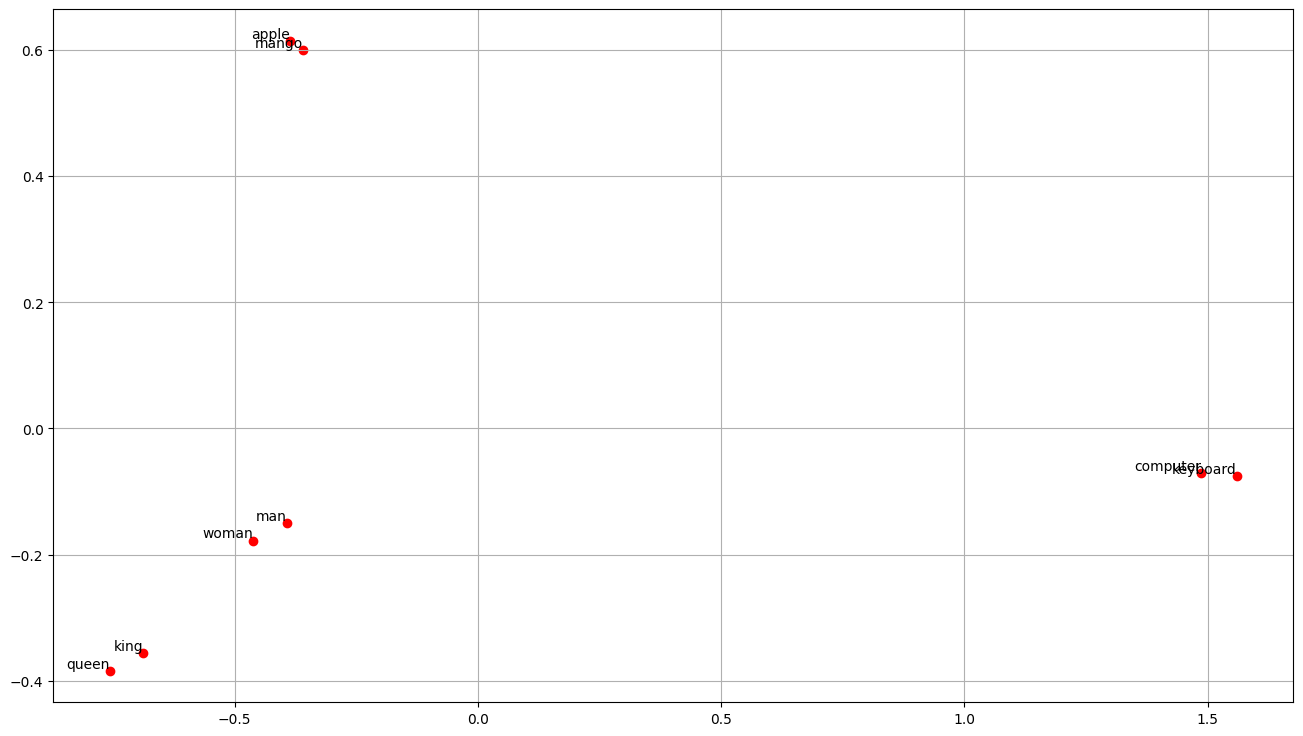

In [18]:
plt.figure(figsize=(16,9))
plt.grid()
plt.scatter(vectors_2d[:,0], vectors_2d[:,1], color = 'r')
for i, word in enumerate(model.index_to_key): 
    plt.annotate(word, xy=(vectors_2d[i,0], vectors_2d[i,1]), 
                ha='right', va='bottom')